# Notebook exploring outliers using pyod

In [ ]:
import platform
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("..")

print(os.getcwd())

if "scripts" in os.getcwd():
    sys.path.append("../../..")
else:
    sys.path.append(".")


pd.set_option("display.max_columns", None)

from func.df_builders.dataframeBuilderFCA import get_df_neigbours_answer_for_all_itemIDs

from sklearn.preprocessing import MinMaxScaler

In [2]:
LOTS_OF_TRAINING_TIME = False # Run all
RUN_OPTIONAL = False # Just skip a few

In [ ]:
from pyod.models.copod import COPOD
from pyod.models.abod import ABOD
from pyod.models.lof import LOF
from pyod.models.iforest import IForest
# from pyod.models.ae1svm import AE1SVM
from pyod.models.knn import KNN
from pyod.models.iforest import IForest
from pyod.models.dif import DIF
from pyod.models.lunar import LUNAR

from pyod.models.pca import PCA as pyodPCA
from sklearn.decomposition import PCA


In [4]:
df, _, _, _ = get_df_neigbours_answer_for_all_itemIDs(join_candidate=True)
df.index = df["TestKey"].astype(int)
df.drop(columns=["TestKey", "CandidateKey"], inplace=True)

df

,Q117_A1,Q117_A2,Q117_A3,Q118_A1,Q118_A2,Q118_A3,Q119_A1,Q119_A2,Q119_A3,Q120_A1,Q120_A2,Q120_A3,Q121_A1,Q121_A2,Q121_A3,Q122_A1,Q122_A2,Q122_A3,Q123_A1,Q123_A2,Q123_A3,Q124_A1,Q124_A2,Q124_A3,Q125_A1,Q125_A2,Q125_A3,Q126_A1,Q126_A2,Q126_A3,Q127_A1,Q127_A2,Q127_A3,Q128_A1,Q128_A2,Q128_A3,Q129_A1,Q129_A2,Q129_A3,Q130_A1,Q130_A2,Q130_A3,Q131_A1,Q131_A2,Q131_A3,Q132_A1,Q132_A2,Q132_A3,Q133_A1,Q133_A2,Q133_A3,Q134_A1,Q134_A2,Q134_A3,Q201_A1,Q201_A2,Q201_A3,Q202_A1,Q202_A2,Q202_A3,Q203_A1,Q203_A2,Q203_A3,Q204_A1,Q204_A2,Q204_A3,Q205_A1,Q205_A2,Q205_A3,Q206_A1,Q206_A2,Q206_A3,Q207_A1,Q207_A2,Q207_A3,Q208_A1,Q208_A2,Q208_A3,Q209_A1,Q209_A2,Q209_A3,Q210_A1,Q210_A2,Q210_A3,Q211_A1,Q211_A2,Q211_A3,Q212_A1,Q212_A2,Q212_A3,Q213_A1,Q213_A2,Q213_A3,Q214_A1,Q214_A2,Q214_A3,Q215_A1,Q215_A2,Q215_A3,Q216_A1,Q216_A2,Q216_A3,Q217_A1,Q217_A2,Q217_A3,Q218_A1,Q218_A2,Q218_A3,Q220_A1,Q220_A2,Q220_A3,Q221_A1,Q221_A2,Q221_A3,Q222_A1,Q222_A2,Q222_A3,Q223_A1,Q223_A2,Q223_A3,Q224_A1,Q224_A2,Q224_A3,Q225_A1,Q225_A2,Q225_A3,Q226_A1,Q226_A2,Q226_A3,Q227_A1,Q227_A2,Q227_A3,Q228_A1,Q228_A2,Q228_A3,Q229_A1,Q229_A2,Q229_A3,Q230_A1,Q230_A2,Q230_A3,Q231_A1,Q231_A2,Q231_A3,Q232_A1,Q232_A2,Q232_A3,Q233_A1,Q233_A2,Q233_A3,Q234_A1,Q234_A2,Q234_A3,Q235_A1,Q235_A2,Q235_A3,Q236_A1,Q236_A2,Q236_A3,Q237_A1,Q237_A2,Q237_A3,Q238_A1,Q238_A2,Q238_A3,Q239_A1,Q239_A2,Q239_A3,Q240_A1,Q240_A2,Q240_A3,Q241_A1,Q241_A2,Q241_A3,Q243_A1,Q243_A2,Q243_A3,Q244_A1,Q244_A2,Q244_A3,Q245_A1,Q245_A2,Q245_A3,Q246_A1,Q246_A2,Q246_A3,Q247_A1,Q247_A2,Q247_A3,Q248_A1,Q248_A2,Q248_A3,Q249_A1,Q249_A2,Q249_A3,Q250_A1,Q250_A2,Q250_A3,Q251_A1,Q251_A2,Q251_A3,Q252_A1,Q252_A2,Q252_A3,Q253_A1,Q253_A2,Q253_A3,Q254_A1,Q254_A2,Q254_A3,Q255_A1,Q255_A2,Q255_A3,Q257_A1,Q257_A2,Q257_A3,Q258_A1,Q258_A2,Q258_A3,Q259_A1,Q259_A2,Q259_A3,Q260_A1,Q260_A2,Q260_A3,Q261_A1,Q261_A2,Q261_A3,Q262_A1,Q262_A2,Q262_A3,Q263_A1,Q263_A2,Q263_A3,Q264_A1,Q264_A2,Q264_A3,Q265_A1,Q265_A2,Q265_A3,Q266_A1,Q266_A2,Q266_A3,Q267_A1,Q267_A2,Q267_A3,Q268_A1,Q268_A2,Q268_A3,Q269_A1,Q269_A2,Q269_A3,Q270_A1,Q270_A2,Q270_A3,Q271_A1,Q271_A2,Q271_A3,Q272_A1,Q272_A2,Q272_A3,Q273_A1,Q273_A2,Q273_A3,Q290_A1,Q290_A2,Q290_A3,Q291_A1,Q291_A2,Q291_A3,Q292_A1,Q292_A2,Q292_A3,Q293_A1,Q293_A2,Q293_A3,Q294_A1,Q294_A2,Q294_A3,Q295_A1,Q295_A2,Q295_A3,Q296_A1,Q296_A2,Q296_A3,Q297_A1,Q297_A2,Q297_A3,Q298_A1,Q298_A2,Q298_A3,Q299_A1,Q299_A2,Q299_A3,Q300_A1,Q300_A2,Q300_A3,Q301_A1,Q301_A2,Q301_A3,Q302_A1,Q302_A2,Q302_A3,Q303_A1,Q303_A2,Q303_A3,Q304_A1,Q304_A2,Q304_A3,Q305_A1,Q305_A2,Q305_A3,Q331_A1,Q331_A2,Q331_A3,Q332_A1,Q332_A2,Q332_A3,Q333_A1,Q333_A2,Q333_A3,Q334_A1,Q334_A2,Q334_A3,Q335_A1,Q335_A2,Q335_A3,Q336_A1,Q336_A2,Q336_A3,Q337_A1,Q337_A2,Q337_A3,Q338_A1,Q338_A2,Q338_A3,Q339_A1,Q339_A2,Q339_A3,Q340_A1,Q340_A2,Q340_A3,Q341_A1,Q341_A2,Q341_A3,Q342_A1,Q342_A2,Q342_A3,Q343_A1,Q343_A2,Q343_A3,Q344_A1,Q344_A2,Q344_A3,Q345_A1,Q345_A2,Q345_A3,Q346_A1,Q346_A2,Q346_A3,Q347_A1,Q347_A2,Q347_A3,Q348_A1,Q348_A2,Q348_A3,Q349_A1,Q349_A2,Q349_A3,Q350_A1,Q350_A2,Q350_A3,Q351_A1,Q351_A2,Q351_A3,Q352_A1,Q352_A2,Q352_A3,Q353_A1,Q353_A2,Q353_A3,Q354_A1,Q354_A2,Q354_A3,Q355_A1,Q355_A2,Q355_A3,Q356_A1,Q356_A2,Q356_A3,Q357_A1,Q357_A2,Q357_A3,Q358_A1,Q358_A2,Q358_A3,Q359_A1,Q359_A2,Q359_A3,Q360_A1,Q360_A2,Q360_A3,Q361_A1,Q361_A2,Q361_A3,Q362_A1,Q362_A2,Q362_A3,Q363_A1,Q363_A2,Q363_A3,Q364_A1,Q364_A2,Q364_A3,Q365_A1,Q365_A2,Q365_A3,Q366_A1,Q366_A2,Q366_A3,Q367_A1,Q367_A2,Q367_A3,Q368_A1,Q368_A2,Q368_A3,Q369_A1,Q369_A2,Q369_A3,Q370_A1,Q370_A2,Q370_A3,Q371_A1,Q371_A2,Q371_A3,Q372_A1,Q372_A2,Q372_A3,Q373_A1,Q373_A2,Q373_A3,Q374_A1,Q374_A2,Q374_A3,Q375_A1,Q375_A2,Q375_A3,Q376_A1,Q376_A2,Q376_A3,Q377_A1,Q377_A2,Q377_A3,Q378_A1,Q378_A2,Q378_A3,Q379_A1,Q379_A2,Q379_A3,Q380_A1,Q380_A2,Q380_A3,Q381_A1,Q381_A2,Q381_A3,Q382_A1,Q382_A2,Q382_A3,Q383_A1,Q383_A2,Q383_A3,Q384_A1,Q384_A2,Q384_A3,Q385_A1,Q385_A2,Q385_A3,Q386_A1,Q386_A2,Q386_A3,Q387_A1,Q387_A2,Q387_A3,Q388_A1,Q388_A2,Q388_A3,Q390_A1,Q390_A2,Q390_A3,Q391_A1,Q391_A2,Q391_A3,Q392_A1,Q392_A2,Q392_A3,Q393_A1,Q393_A2,Q393_A3,Q394_A1,Q394_A2

## X_train, X_test

In [5]:
df = df.sample(frac=1.)
LEN_TRAIN = np.round(0.99 * len(df), 0).astype(int)
LEN_TEST = len(df) - LEN_TRAIN
df

,Q117_A1,Q117_A2,Q117_A3,Q118_A1,Q118_A2,Q118_A3,Q119_A1,Q119_A2,Q119_A3,Q120_A1,Q120_A2,Q120_A3,Q121_A1,Q121_A2,Q121_A3,Q122_A1,Q122_A2,Q122_A3,Q123_A1,Q123_A2,Q123_A3,Q124_A1,Q124_A2,Q124_A3,Q125_A1,Q125_A2,Q125_A3,Q126_A1,Q126_A2,Q126_A3,Q127_A1,Q127_A2,Q127_A3,Q128_A1,Q128_A2,Q128_A3,Q129_A1,Q129_A2,Q129_A3,Q130_A1,Q130_A2,Q130_A3,Q131_A1,Q131_A2,Q131_A3,Q132_A1,Q132_A2,Q132_A3,Q133_A1,Q133_A2,Q133_A3,Q134_A1,Q134_A2,Q134_A3,Q201_A1,Q201_A2,Q201_A3,Q202_A1,Q202_A2,Q202_A3,Q203_A1,Q203_A2,Q203_A3,Q204_A1,Q204_A2,Q204_A3,Q205_A1,Q205_A2,Q205_A3,Q206_A1,Q206_A2,Q206_A3,Q207_A1,Q207_A2,Q207_A3,Q208_A1,Q208_A2,Q208_A3,Q209_A1,Q209_A2,Q209_A3,Q210_A1,Q210_A2,Q210_A3,Q211_A1,Q211_A2,Q211_A3,Q212_A1,Q212_A2,Q212_A3,Q213_A1,Q213_A2,Q213_A3,Q214_A1,Q214_A2,Q214_A3,Q215_A1,Q215_A2,Q215_A3,Q216_A1,Q216_A2,Q216_A3,Q217_A1,Q217_A2,Q217_A3,Q218_A1,Q218_A2,Q218_A3,Q220_A1,Q220_A2,Q220_A3,Q221_A1,Q221_A2,Q221_A3,Q222_A1,Q222_A2,Q222_A3,Q223_A1,Q223_A2,Q223_A3,Q224_A1,Q224_A2,Q224_A3,Q225_A1,Q225_A2,Q225_A3,Q226_A1,Q226_A2,Q226_A3,Q227_A1,Q227_A2,Q227_A3,Q228_A1,Q228_A2,Q228_A3,Q229_A1,Q229_A2,Q229_A3,Q230_A1,Q230_A2,Q230_A3,Q231_A1,Q231_A2,Q231_A3,Q232_A1,Q232_A2,Q232_A3,Q233_A1,Q233_A2,Q233_A3,Q234_A1,Q234_A2,Q234_A3,Q235_A1,Q235_A2,Q235_A3,Q236_A1,Q236_A2,Q236_A3,Q237_A1,Q237_A2,Q237_A3,Q238_A1,Q238_A2,Q238_A3,Q239_A1,Q239_A2,Q239_A3,Q240_A1,Q240_A2,Q240_A3,Q241_A1,Q241_A2,Q241_A3,Q243_A1,Q243_A2,Q243_A3,Q244_A1,Q244_A2,Q244_A3,Q245_A1,Q245_A2,Q245_A3,Q246_A1,Q246_A2,Q246_A3,Q247_A1,Q247_A2,Q247_A3,Q248_A1,Q248_A2,Q248_A3,Q249_A1,Q249_A2,Q249_A3,Q250_A1,Q250_A2,Q250_A3,Q251_A1,Q251_A2,Q251_A3,Q252_A1,Q252_A2,Q252_A3,Q253_A1,Q253_A2,Q253_A3,Q254_A1,Q254_A2,Q254_A3,Q255_A1,Q255_A2,Q255_A3,Q257_A1,Q257_A2,Q257_A3,Q258_A1,Q258_A2,Q258_A3,Q259_A1,Q259_A2,Q259_A3,Q260_A1,Q260_A2,Q260_A3,Q261_A1,Q261_A2,Q261_A3,Q262_A1,Q262_A2,Q262_A3,Q263_A1,Q263_A2,Q263_A3,Q264_A1,Q264_A2,Q264_A3,Q265_A1,Q265_A2,Q265_A3,Q266_A1,Q266_A2,Q266_A3,Q267_A1,Q267_A2,Q267_A3,Q268_A1,Q268_A2,Q268_A3,Q269_A1,Q269_A2,Q269_A3,Q270_A1,Q270_A2,Q270_A3,Q271_A1,Q271_A2,Q271_A3,Q272_A1,Q272_A2,Q272_A3,Q273_A1,Q273_A2,Q273_A3,Q290_A1,Q290_A2,Q290_A3,Q291_A1,Q291_A2,Q291_A3,Q292_A1,Q292_A2,Q292_A3,Q293_A1,Q293_A2,Q293_A3,Q294_A1,Q294_A2,Q294_A3,Q295_A1,Q295_A2,Q295_A3,Q296_A1,Q296_A2,Q296_A3,Q297_A1,Q297_A2,Q297_A3,Q298_A1,Q298_A2,Q298_A3,Q299_A1,Q299_A2,Q299_A3,Q300_A1,Q300_A2,Q300_A3,Q301_A1,Q301_A2,Q301_A3,Q302_A1,Q302_A2,Q302_A3,Q303_A1,Q303_A2,Q303_A3,Q304_A1,Q304_A2,Q304_A3,Q305_A1,Q305_A2,Q305_A3,Q331_A1,Q331_A2,Q331_A3,Q332_A1,Q332_A2,Q332_A3,Q333_A1,Q333_A2,Q333_A3,Q334_A1,Q334_A2,Q334_A3,Q335_A1,Q335_A2,Q335_A3,Q336_A1,Q336_A2,Q336_A3,Q337_A1,Q337_A2,Q337_A3,Q338_A1,Q338_A2,Q338_A3,Q339_A1,Q339_A2,Q339_A3,Q340_A1,Q340_A2,Q340_A3,Q341_A1,Q341_A2,Q341_A3,Q342_A1,Q342_A2,Q342_A3,Q343_A1,Q343_A2,Q343_A3,Q344_A1,Q344_A2,Q344_A3,Q345_A1,Q345_A2,Q345_A3,Q346_A1,Q346_A2,Q346_A3,Q347_A1,Q347_A2,Q347_A3,Q348_A1,Q348_A2,Q348_A3,Q349_A1,Q349_A2,Q349_A3,Q350_A1,Q350_A2,Q350_A3,Q351_A1,Q351_A2,Q351_A3,Q352_A1,Q352_A2,Q352_A3,Q353_A1,Q353_A2,Q353_A3,Q354_A1,Q354_A2,Q354_A3,Q355_A1,Q355_A2,Q355_A3,Q356_A1,Q356_A2,Q356_A3,Q357_A1,Q357_A2,Q357_A3,Q358_A1,Q358_A2,Q358_A3,Q359_A1,Q359_A2,Q359_A3,Q360_A1,Q360_A2,Q360_A3,Q361_A1,Q361_A2,Q361_A3,Q362_A1,Q362_A2,Q362_A3,Q363_A1,Q363_A2,Q363_A3,Q364_A1,Q364_A2,Q364_A3,Q365_A1,Q365_A2,Q365_A3,Q366_A1,Q366_A2,Q366_A3,Q367_A1,Q367_A2,Q367_A3,Q368_A1,Q368_A2,Q368_A3,Q369_A1,Q369_A2,Q369_A3,Q370_A1,Q370_A2,Q370_A3,Q371_A1,Q371_A2,Q371_A3,Q372_A1,Q372_A2,Q372_A3,Q373_A1,Q373_A2,Q373_A3,Q374_A1,Q374_A2,Q374_A3,Q375_A1,Q375_A2,Q375_A3,Q376_A1,Q376_A2,Q376_A3,Q377_A1,Q377_A2,Q377_A3,Q378_A1,Q378_A2,Q378_A3,Q379_A1,Q379_A2,Q379_A3,Q380_A1,Q380_A2,Q380_A3,Q381_A1,Q381_A2,Q381_A3,Q382_A1,Q382_A2,Q382_A3,Q383_A1,Q383_A2,Q383_A3,Q384_A1,Q384_A2,Q384_A3,Q385_A1,Q385_A2,Q385_A3,Q386_A1,Q386_A2,Q386_A3,Q387_A1,Q387_A2,Q387_A3,Q388_A1,Q388_A2,Q388_A3,Q390_A1,Q390_A2,Q390_A3,Q391_A1,Q391_A2,Q391_A3,Q392_A1,Q392_A2,Q392_A3,Q393_A1,Q393_A2,Q393_A3,Q394_A1,Q394_A2

In [6]:
scaler = MinMaxScaler()

scaler.fit(df[:LEN_TRAIN])

MinMaxScaler()

In [7]:
X_train = scaler.transform(df)
X_train, len(X_train)

(array([[0., 0., 0., ..., 0., 1., 0.],
        [0., 0., 0., ..., 0., 1., 0.],
        [0., 0., 0., ..., 0., 1., 0.],
        ...,
        [0., 0., 0., ..., 0., 1., 0.],
        [0., 0., 0., ..., 0., 1., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 160064)

In [8]:
X_test = scaler.transform(df[LEN_TRAIN:])
X_test, len(X_test)

(array([[0., 0., 0., ..., 0., 1., 0.],
        [0., 0., 0., ..., 0., 1., 0.],
        [0., 0., 0., ..., 0., 1., 0.],
        ...,
        [0., 0., 0., ..., 0., 1., 0.],
        [0., 0., 0., ..., 0., 1., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 1601)

## Helpers

In [9]:
def data_generator(X, batch_size=1000):
    for i in range(0, len(X), batch_size):
        yield X[i:i + batch_size]

# Functie om een model te trainen in batches
def process_batches(model, X, batch_size=1000):
    anomaly_scores = []
    
    # TODO : shuffle, and fit more times

    # Train op batches
    for batch in data_generator(X, batch_size):
        model.fit(batch)  # Train op de huidige batch
        batch_scores = model.decision_function(batch)  # Verkrijg anomalie scores voor de batch
        anomaly_scores.extend(batch_scores)  # Voeg scores toe aan de lijst
    
    return np.array(anomaly_scores), model

# anomaly_scores = process_batches(model, X, batch_size=1000)

outliers = {}
outliers["TestKey"] = df.index.to_list()
results = {
    "model" : [],
    "em" : [],
    "mv" : []
}
df_is_anomaly = pd.DataFrame(index=df.index)
df_anomaly_scores = pd.DataFrame(index=df.index)
df_results = pd.DataFrame(columns=["model", "EM", "MV"])

def predict_model(model, name, X_train, X_test, contamination, df_is_anomaly, results):
    print(f"Training {name}!")
    
    anomaly_scores, model = process_batches(model, X_train)

    # Bepaal anomalieën op basis van de scores (bijvoorbeeld top 5% als anomalieën)
    threshold = np.percentile(anomaly_scores, 100 - 100*contamination)  # Drempelwaarde instellen
    is_anomaly = anomaly_scores > threshold
    
    df_anomaly_scores[name] = anomaly_scores
    df_is_anomaly[name] = is_anomaly.astype(int)

    print(f"Aantal gedetecteerde anomalieën: {df_is_anomaly[name].sum()}")

    emmv_waarden = emmv_scores(model, X_test)
    results["model"].append(name)
    results["em"].append(emmv_waarden["em"])
    results["mv"].append(emmv_waarden["mv"])
    print(f"emmv waarden", emmv_waarden)

    # df_answers.to_csv(f"../csv/{name}-mike.csv")
    
    return df_is_anomaly[name]

## Algoritms

EMMV metrics:

EM: Lower better
MV: Higher better

## Local Outlier Factor

In [10]:
model = LOF(contamination=0.05)
is_anomaly = predict_model(model=model, name='lof_05', X_train=X_train, X_test=X_test, contamination=0.05, df_is_anomaly=df_is_anomaly, results=results)

Training lof_05!
Aantal gedetecteerde anomalieën: 8004
type lim_inf, lim_sup: <class 'numpy.ndarray'> <class 'numpy.ndarray'>
emmv waarden {'em': np.float64(0.005043816364772018), 'mv': np.float64(9.999999999999997e-61)}


In [11]:
model = LOF(contamination=0.10)
is_anomaly = predict_model(model=model, name='lof_10', X_train=X_train, X_test=X_test, contamination=0.05, df_is_anomaly=df_is_anomaly, results=results)

Training lof_10!
Aantal gedetecteerde anomalieën: 8004
type lim_inf, lim_sup: <class 'numpy.ndarray'> <class 'numpy.ndarray'>
emmv waarden {'em': np.float64(0.005043816364772018), 'mv': np.float64(9.999999999999997e-61)}


In [12]:
model = LOF(contamination=0.01, leaf_size=60, n_neighbors=30)
is_anomaly = predict_model(model=model, name='lof_01_leaf_60_neighbours_30', X_train=X_train, X_test=X_test, contamination=0.05, df_is_anomaly=df_is_anomaly, results=results)

Training lof_01_leaf_60_neighbours_30!
Aantal gedetecteerde anomalieën: 8004
type lim_inf, lim_sup: <class 'numpy.ndarray'> <class 'numpy.ndarray'>
emmv waarden {'em': np.float64(0.005043816364772018), 'mv': np.float64(9.999999999999997e-61)}


In [13]:
# model = LOF(metric='manhattan', contamination=0.05)
# is_anomaly = predict_model(model=model, name='lof_05_manhattan', X_train=X_train, X_test=X_test, contamination=0.05, df_is_anomaly=df_is_anomaly, results=results)

In [14]:
if LOTS_OF_TRAINING_TIME:
    model = LOF(metric='manhattan', contamination=0.05)
    is_anomaly = predict_model(model=model, name='lof_manhattan', X_train=X_train, X_test=X_test, contamination=0.05, df_is_anomaly=df_is_anomaly, results=results)

In [15]:
# lof_outliers2

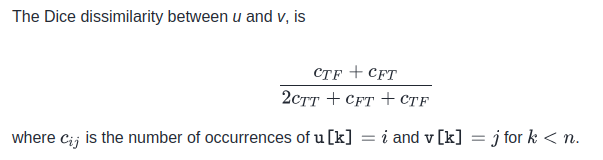
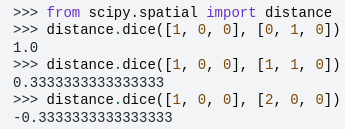
I don't get the distance, but it seems different

In [16]:
if LOTS_OF_TRAINING_TIME:
    model = LOF(metric='dice', contamination=0.05)
    model.fit(df)
    outliers["lof_dice"] = model.predict(df)

## LOF Hamming

The Hamming distance between 1-D arrays u and v, is simply the proportion of disagreeing components in u and v. 

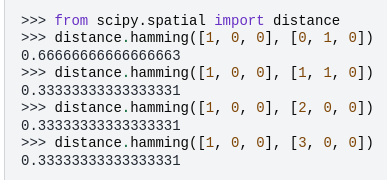

In [17]:
if RUN_OPTIONAL or LOTS_OF_TRAINING_TIME:
    model = LOF(metric='hamming', contamination=0.05)
    model.fit(df)
    outliers["lof_hamming"] = model.predict(df)

## Linear or PCA based

Principal component analysis (PCA) can be used in detecting outliers. PCA is a linear dimensionality reduction using Singular Value Decomposition of the data to project it to a lower dimensional space.

In this procedure, covariance matrix of the data can be decomposed to orthogonal vectors, called eigenvectors, associated with eigenvalues. The eigenvectors with high eigenvalues capture most of the variance in the data.

Therefore, a low dimensional hyperplane constructed by k eigenvectors can capture most of the variance in the data. However, outliers are different from normal data points, which is more obvious on the hyperplane constructed by the eigenvectors with small eigenvalues.

Therefore, outlier scores can be obtained as the sum of the projected distance of a sample on all eigenvectors.

In [18]:
from pyod.models.pca import PCA as pyodPCA

In [19]:
model = pyodPCA(n_components=0.95, svd_solver="full", contamination=0.05)
is_anomaly = predict_model(model=model, name='pca', X_train=X_train, X_test=X_test, contamination=0.05, df_is_anomaly=df_is_anomaly, results=results)

Training pca!
Aantal gedetecteerde anomalieën: 8004
type lim_inf, lim_sup: <class 'numpy.ndarray'> <class 'numpy.ndarray'>
emmv waarden {'em': np.float64(0.005043816364772018), 'mv': np.float64(9.999999999999997e-61)}


In [20]:
model = COPOD(contamination=0.05, n_jobs=2)
is_anomaly = predict_model(model=model, name='copod', X_train=X_train, X_test=X_test, contamination=0.05, df_is_anomaly=df_is_anomaly, results=results)

Training copod!


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    1.5s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concu

Aantal gedetecteerde anomalieën: 8004
type lim_inf, lim_sup: <class 'numpy.ndarray'> <class 'numpy.ndarray'>


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.6s finished


emmv waarden {'em': np.float64(0.005043816364772018), 'mv': np.float64(9.999999999999997e-61)}


In [21]:
model = LUNAR(contamination=0.05)
is_anomaly = predict_model(model=model, name='lunar', X_train=X_train, X_test=X_test, contamination=0.05, df_is_anomaly=df_is_anomaly, results=results)

Training lunar!
Aantal gedetecteerde anomalieën: 8004
type lim_inf, lim_sup: <class 'numpy.ndarray'> <class 'numpy.ndarray'>
emmv waarden {'em': np.float64(0.005043816364772018), 'mv': np.float64(9.999999999999997e-61)}


In [22]:
# minimum 44 min
if LOTS_OF_TRAINING_TIME:
    model = KNN(contamination=0.05)
    is_anomaly = predict_model(model=model, name='knn', X_train=X_train, X_test=X_test, contamination=0.05, df_is_anomaly=df_is_anomaly, results=results)


In [23]:
model = IForest(contamination=0.05)
is_anomaly = predict_model(model=model, name='iforest', X_train=X_train, X_test=X_test, contamination=0.05, df_is_anomaly=df_is_anomaly, results=results)


Training iforest!
Aantal gedetecteerde anomalieën: 8004
type lim_inf, lim_sup: <class 'numpy.ndarray'> <class 'numpy.ndarray'>
emmv waarden {'em': np.float64(0.005044458239600249), 'mv': np.float64(9.999999999999997e-61)}


In [24]:
model = DIF(contamination=0.05)
is_anomaly = predict_model(model=model, name='deep_iforest', X_train=X_train, X_test=X_test, contamination=0.05, df_is_anomaly=df_is_anomaly, results=results)

Training deep_iforest!


/home/miked/code/dep2-g2/venv/lib/python3.12/site-packages/sklearn/ensemble/_iforest.py:308: UserWarning: max_samples (256) is greater than the total number of samples (64). max_samples will be set to n_samples for estimation.
  warn(
/home/miked/code/dep2-g2/venv/lib/python3.12/site-packages/sklearn/ensemble/_iforest.py:308: UserWarning: max_samples (256) is greater than the total number of samples (64). max_samples will be set to n_samples for estimation.
  warn(
/home/miked/code/dep2-g2/venv/lib/python3.12/site-packages/sklearn/ensemble/_iforest.py:308: UserWarning: max_samples (256) is greater than the total number of samples (64). max_samples will be set to n_samples for estimation.
  warn(
/home/miked/code/dep2-g2/venv/lib/python3.12/site-packages/sklearn/ensemble/_iforest.py:308: UserWarning: max_samples (256) is greater than the total number of samples (64). max_samples will be set to n_samples for estimation.
  warn(
/home/miked/code/dep2-g2/venv/lib/python3.12/site-packages/s

Aantal gedetecteerde anomalieën: 8004
type lim_inf, lim_sup: <class 'numpy.ndarray'> <class 'numpy.ndarray'>
emmv waarden {'em': np.float64(0.025248671512054965), 'mv': np.float64(9.999999999999997e-61)}


## Wanna try-out
 
- ABOD (Angle based outlier detection) or FastABOD
- COPOD
- KNN
- IForest


In [25]:
outliers

{'TestKey': [86014,
  144603,
  50735,
  97053,
  104243,
  17326,
  124638,
  23540,
  145101,
  62097,
  4974,
  71884,
  95747,
  46274,
  142233,
  53425,
  42627,
  90957,
  74477,
  58014,
  27183,
  21115,
  128457,
  122329,
  69700,
  132370,
  8774,
  40846,
  9435,
  46252,
  55281,
  115639,
  143369,
  143847,
  124054,
  46507,
  150234,
  83723,
  55859,
  17251,
  13930,
  14350,
  73813,
  71539,
  136788,
  30354,
  86670,
  45055,
  97275,
  68601,
  14258,
  20743,
  99753,
  131715,
  53486,
  139145,
  77674,
  133548,
  51249,
  11343,
  66174,
  54713,
  79532,
  123910,
  133423,
  130338,
  19050,
  100004,
  111268,
  85159,
  76310,
  131112,
  75765,
  146641,
  7499,
  138432,
  13467,
  106012,
  18589,
  105931,
  80429,
  92648,
  17626,
  14731,
  124522,
  127585,
  37658,
  380,
  9094,
  123518,
  35302,
  97056,
  74815,
  94081,
  147193,
  13378,
  59963,
  8628,
  138221,
  71206,
  53666,
  121385,
  27005,
  62193,
  65053,
  105419,
  126443,

In [26]:
df_is_anomaly

,lof_05,lof_10,lof_01_leaf_60_neighbours_30,pca,copod,lunar,iforest,deep_iforest
TestKey,,,,,,,,
86014,1,1,1,0,0,0,0,0
144603,0,0,0,0,0,0,0,0
50735,0,0,0,0,0,0,0,0
97053,0,0,0,0,0,0,0,0
104243,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
138530,0,0,0,0,0,0,0,0
11660,0,0,0,0,0,0,0,0
28351,0,0,0,0,0,0,0,0


In [27]:
df_outliers = df_is_anomaly
columns = df_outliers.columns.to_list()
df_outliers['count'] =  df_outliers[columns].sum(axis=1)
df_outliers['pyod % outlier'] = df_outliers['count'] / len(columns)
df_outliers

,lof_05,lof_10,lof_01_leaf_60_neighbours_30,pca,copod,lunar,iforest,deep_iforest,count,pyod % outlier
TestKey,,,,,,,,,,
86014,1,1,1,0,0,0,0,0,3,0.375
144603,0,0,0,0,0,0,0,0,0,0.000
50735,0,0,0,0,0,0,0,0,0,0.000
97053,0,0,0,0,0,0,0,0,0,0.000
104243,0,0,0,0,0,0,0,0,0,0.000
...,...,...,...,...,...,...,...,...,...,...
138530,0,0,0,0,0,0,0,0,0,0.000
11660,0,0,0,0,0,0,0,0,0,0.000
28351,0,0,0,0,0,0,0,0,0,0.000


In [28]:
df_outliers['count'].value_counts()

count
0    138406
1      8498
2      3978
3      2850
8      1952
4      1722
7      1473
5       897
6       288
Name: count, dtype: int64

In [29]:
TRESHOLD = 0.7
df_outliers["is_anomaly"] = np.where(df_outliers['pyod % outlier'] >= TRESHOLD, 1, 0)
df_outliers

,lof_05,lof_10,lof_01_leaf_60_neighbours_30,pca,copod,lunar,iforest,deep_iforest,count,pyod % outlier,is_anomaly
TestKey,,,,,,,,,,,
86014,1,1,1,0,0,0,0,0,3,0.375,0
144603,0,0,0,0,0,0,0,0,0,0.000,0
50735,0,0,0,0,0,0,0,0,0,0.000,0
97053,0,0,0,0,0,0,0,0,0,0.000,0
104243,0,0,0,0,0,0,0,0,0,0.000,0
...,...,...,...,...,...,...,...,...,...,...,...
138530,0,0,0,0,0,0,0,0,0,0.000,0
11660,0,0,0,0,0,0,0,0,0,0.000,0
28351,0,0,0,0,0,0,0,0,0,0.000,0


In [30]:
pd.DataFrame(results)

,model,em,mv
0,lof_05,0.005044,1.000000e-60
1,lof_10,0.005044,1.000000e-60
2,lof_01_leaf_60_neighbours_30,0.005044,1.000000e-60
3,pca,0.005044,1.000000e-60
4,copod,0.005044,1.000000e-60
5,lunar,0.005044,1.000000e-60
6,iforest,0.005044,1.000000e-60
7,deep_iforest,0.025249,1.000000e-60


In [31]:
df_outliers.to_csv("../csv/pyod_ensemble.csv", index=True)


In [32]:
df_is_anomaly["is_anomaly"].sum()

np.int64(3713)